# Sentiment classification

1. **BiLSTM** with **embeddings trained from scratch** (no external vectors).
2. **BiLSTM** with **GloVe** (via **gensim** `glove-wiki-gigaword-100`).
3. **BERT** sequence classifier via Hugging Face `transformers`.
4. **FastText supervised** (`fasttext.train_supervised`): linear classifier over word / char *n*-grams with **pretrained English Wikipedia vectors** (`wiki.en.vec`, downloaded once) — fast on CPU, no PyTorch neural nets in your notebook.

# Install dependencies

In [ ]:
# Run once if needed (no torchtext — its C++ extension often breaks when PyTorch / torchtext versions disagree)
!pip install -U torch torchvision datasets transformers tqdm scikit-learn gensim fasttext

# Basic imports, initialization

In [ ]:
# Import necessary libraries
import random
import re
from collections import Counter
from tqdm.auto import tqdm
import numpy as np


# Import PyTorch libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence


# Repository of various datasets
from datasets import load_dataset


# Evaluation metrics
from sklearn.metrics import accuracy_score, f1_score


# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Choose computational device
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    # For apple silicon support (macbooks and macs)
    device = torch.device("mps")
elif torch.cuda.is_available():
    # For GPU support
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

# Download data

In [ ]:
# Downloading the dataset from huggingface repository

# IMDB: labels 0 = negative, 1 = positive
NUM_CLASSES = 2
raw = load_dataset("imdb")
raw

In [ ]:
# Lets see what is stored in the dataset

from pprint import pprint

pprint(raw['train'][0], width=80)

In [ ]:
# Optional: subsample for quicker experiments

MAX_TRAIN, MAX_TEST = 10000, 2000
train_rows = raw["train"].shuffle(SEED).select(range(min(MAX_TRAIN, len(raw["train"]))))
test_rows = raw["test"].select(range(min(MAX_TEST, len(raw["test"]))))

train_texts = train_rows["text"]
train_labels = train_rows["label"]
test_texts = test_rows["text"]
test_labels = test_rows["label"]

# 1. BiLSTM without pre-trained embeddings

In [ ]:
# We need functions for preprocessing texts

import json
from pathlib import Path


def basic_english_tokenize(text: str):
    """Rough equivalent of torchtext `get_tokenizer('basic_english')`: lowercase word tokens."""
    return re.findall(r"[a-z0-9]+", text.lower())


class SimpleVocab:
    def __init__(self, stoi: dict, itos: list, default_index: int):
        self.stoi = stoi
        self.itos = itos
        self._default = default_index

    def __call__(self, tokens):
        return [self.stoi.get(t, self._default) for t in tokens]

    def __getitem__(self, token):
        return self.stoi[token]

    def __len__(self):
        return len(self.itos)

    def set_default_index(self, idx: int):
        self._default = idx

    def get_itos(self):
        return list(self.itos)

    def save(self, path: str):
        p = Path(path)
        p.parent.mkdir(parents=True, exist_ok=True)
        with p.open("w", encoding="utf-8") as f:
            json.dump(
                {"stoi": self.stoi, "itos": self.itos, "default_index": self._default},
                f,
                ensure_ascii=False,
            )

    @classmethod
    def load(cls, path: str):
        with Path(path).open(encoding="utf-8") as f:
            d = json.load(f)
            
        return cls(d["stoi"], d["itos"], d["default_index"])


def build_vocab_from_iterator(token_iter, min_freq: int, specials: list):
    counter = Counter()
    for tokens in token_iter:
        counter.update(tokens)
    stoi, itos = {}, []

    for s in specials:
        stoi[s] = len(itos)
        itos.append(s)

    for word, c in counter.most_common():
        if c < min_freq:
            continue
        if word in stoi:
            continue
        stoi[word] = len(itos)
        itos.append(word)
        
    unk_ix = stoi["<unk>"]
    return SimpleVocab(stoi, itos, default_index=unk_ix)

In [ ]:
# For classical NNs, we need to build a vocabulary from the training data

tokenizer = basic_english_tokenize

def yield_tokens(texts):
    for t in texts:
        yield tokenizer(t)

MIN_FREQ = 5
vocab = build_vocab_from_iterator(
    yield_tokens(train_texts),
    min_freq=MIN_FREQ,
    specials=["<pad>", "<unk>"],
)
vocab.set_default_index(vocab["<unk>"])
PAD_IX = vocab["<pad>"]
print("Vocab size:", len(vocab))
VOCAB_PATH = "imdb_bilstm_vocab.json"
vocab.save(VOCAB_PATH)
print("Saved vocabulary to", VOCAB_PATH)

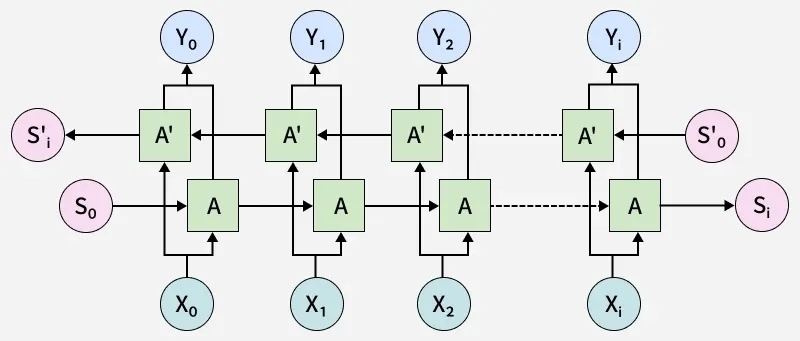

In [ ]:
# Create a BiLSTM architecture

class BiLSTMClassifier(nn.Module):
    """Sentiment classifier: Embedding -> BiLSTM -> max pooling over time -> linear."""

    def __init__(
        self,
        vocab_size,
        padding_idx,
        embed_dim,
        hidden_dim,
        num_classes,
        embedding_layer=None,
        dropout=0.5,
    ):
        super().__init__()
        if embedding_layer is not None:
            self.embedding = embedding_layer
            embed_dim = embedding_layer.embedding_dim
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.padding_idx = padding_idx

    def forward(self, token_ids):
        # token_ids: (batch, seq)
        emb = self.dropout(self.embedding(token_ids))
        out, _ = self.lstm(emb)
        # Max pooling over valid positions (ignore pad)
        mask = token_ids != self.padding_idx
        out = out.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        pooled, _ = out.max(dim=1)
        logits = self.fc(self.dropout(pooled))
        return logits

In [ ]:
# Create a BiLSTM model

EMBED_DIM = 128
HIDDEN = 128
NUM_CLASSES = 2

lstm_scratch = BiLSTMClassifier(
    vocab_size=len(vocab),
    padding_idx=PAD_IX,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN,
    num_classes=NUM_CLASSES,
)

num_params = sum(p.numel() for p in lstm_scratch.parameters())
print(f"Number of parameters in lstm_scratch: {num_params}")

In [ ]:
# Pre-processing texts and padding

class TextClfDataset(Dataset):
    def __init__(self, texts, labels, vocab, tokenizer):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        ids = torch.tensor(self.vocab(self.tokenizer(self.texts[i])), dtype=torch.long)
        y = int(self.labels[i])
        return ids, y


def lstm_collate(batch):
    seqs, labels = zip(*batch)
    padded = pad_sequence(seqs, batch_first=True, padding_value=PAD_IX)
    y = torch.tensor(labels, dtype=torch.long)
    return padded, y


BATCH_SIZE = 64
train_ds = TextClfDataset(train_texts, train_labels, vocab, tokenizer)
test_ds = TextClfDataset(test_texts, test_labels, vocab, tokenizer)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lstm_collate)
# Same data as training, no shuffle — for per-epoch train accuracy / F1
train_eval_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lstm_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lstm_collate)

In [ ]:
# Training and evaluation loops

def evaluate_lstm(model, data_loader, split="test"):
    model.eval()
    preds, gold = [], []
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            logits = model(x)
            preds.extend(logits.argmax(-1).cpu().numpy())
            gold.extend(y.numpy())

    acc = round(accuracy_score(gold, preds), 4)
    macro_f1 = round(f1_score(gold, preds, average="macro"), 4)
    print(f"  {split} accuracy:", acc)
    print(f"  {split} macro-F1:", macro_f1)
    return acc, macro_f1


def train_lstm(model, epochs=1, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        losses = []
        for x, y in tqdm(train_loader, desc=f"LSTM epoch {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
            
        print(f"  train loss: {np.mean(losses):.4f}")
        evaluate_lstm(model, train_eval_loader, split="train")

    return model

In [ ]:
print("Training LSTM (scratch embeddings)...")
train_lstm(lstm_scratch, epochs=5, lr=2e-3)
print("Done.")

print("Evaluating LSTM (scratch embeddings)...")
evaluate_lstm(lstm_scratch, test_loader, split="test")
print("Done.")

MODEL_SAVE_PATH = "lstm_scratch.pth"
torch.save(lstm_scratch.state_dict(), MODEL_SAVE_PATH)
print(f"Trained LSTM model saved to {MODEL_SAVE_PATH}")

In [ ]:
# Load model from disk, do inference

if "lstm_scratch" not in locals() or lstm_scratch is None:
    lstm_scratch = BiLSTMClassifier(
        vocab_size=len(vocab),
        padding_idx=PAD_IX,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN,
        num_classes=NUM_CLASSES,
    )
    
    MODEL_LOAD_PATH = "lstm_scratch.pth"
    lstm_scratch.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    lstm_scratch = lstm_scratch.to(device)
    lstm_scratch.eval()


# Example: Test the trained model on some new texts
examples = [
    "This movie was absolutely wonderful!",
    "I hated this film. It was terrible.",
    "A truly average experience, nothing special.",
    "Brilliant acting and great story.",
    "Worst movie ever.",
]

# Same tokenization as training (`tokenizer` + `vocab(...)`).
def preprocess_texts(texts, vocab, tokenizer, pad_ix, max_len=100):
    seqs = []
    for text in texts:
        ids = vocab(tokenizer(text))
        padded = ids[:max_len] + [pad_ix] * max(0, max_len - len(ids))
        seqs.append(padded[:max_len])
        
    return torch.tensor(seqs, dtype=torch.long)


X_test = preprocess_texts(examples, vocab, tokenizer, PAD_IX, max_len=100)

with torch.no_grad():
    logits = lstm_scratch(X_test.to(device))
    preds = logits.argmax(dim=-1).cpu().numpy()

label_map = {0: "Negative", 1: "Positive"}
for text, pred in zip(examples, preds):
    print(f"Text: {text}\nPredicted label: {label_map.get(pred, pred)}\n")

# 2. BiLSTM + pre-trained GloVe

In [ ]:
import gensim.downloader as api


# Load GloVe embeddings

GLOVE_DIM = 100
print("Loading glove-wiki-gigaword-100 (~128MB on first download)...")
glove_kv = api.load("glove-wiki-gigaword-100")

pretrained = torch.zeros(len(vocab), GLOVE_DIM)
for i, word in enumerate(vocab.get_itos()):
    if word in glove_kv:
        pretrained[i] = torch.from_numpy(glove_kv[word].copy())

emb_glove = nn.Embedding.from_pretrained(
    pretrained,
    padding_idx=PAD_IX,
    freeze=False,
)

In [ ]:
# Lets see what is stored in the GloVe embedding matrix

sample_words = ["good", "bad", "movie", "film", "the"]
for w in sample_words:
    if w not in vocab.stoi:
        print(f"{w!r}: not in vocab")
        continue

    i = vocab.stoi[w]
    vec = emb_glove.weight[i].detach()
    dims_str = ", ".join(f"{x:.3f}" for x in vec[:12].tolist())
    print(f"{w!r} (idx={i}): first 12 dims = [{dims_str}] ... (full dim={vec.numel()})")

In [ ]:
lstm_glove = BiLSTMClassifier(
    vocab_size=len(vocab),
    padding_idx=PAD_IX,
    embed_dim=GLOVE_DIM,
    hidden_dim=HIDDEN,
    num_classes=NUM_CLASSES,
    embedding_layer=emb_glove,
)

print("Training LSTM (GloVe init)...")
train_lstm(lstm_glove, epochs=5, lr=1e-3)
print("Done.")

print("Evaluating LSTM (GloVe init)...")
evaluate_lstm(lstm_glove, test_loader, split="test")
print("Done.")

GLOVE_LSTM_SAVE_PATH = "lstm_glove.pth"
torch.save(lstm_glove.state_dict(), GLOVE_LSTM_SAVE_PATH)
print(f"Trained LSTM (GloVe) saved to {GLOVE_LSTM_SAVE_PATH}")

In [ ]:
# Load GloVe BiLSTM and conduct inference

if "lstm_glove" not in locals() or lstm_glove is None:
    lstm_glove = BiLSTMClassifier(
        vocab_size=len(vocab),
        padding_idx=PAD_IX,
        embed_dim=GLOVE_DIM,
        hidden_dim=HIDDEN,
        num_classes=NUM_CLASSES,
        embedding_layer=emb_glove,
    )

    GLOVE_LSTM_SAVE_PATH = "lstm_glove.pth"
    lstm_glove.load_state_dict(torch.load(GLOVE_LSTM_SAVE_PATH, map_location=device))
    lstm_glove = lstm_glove.to(device)
    lstm_glove.eval()


# Example: Test the trained model on some new texts
test_texts = [
    "This movie was absolutely wonderful!",
    "I hated this film. It was terrible.",
    "A truly average experience, nothing special.",
    "Brilliant acting and great story.",
    "Worst movie ever.",
]

# Same tokenization as training (`tokenizer` + `vocab(...)`).
def preprocess_texts(texts, vocab, tokenizer, pad_ix, max_len=100):
    seqs = []
    for text in texts:
        ids = vocab(tokenizer(text))
        padded = ids[:max_len] + [pad_ix] * max(0, max_len - len(ids))
        seqs.append(padded[:max_len])
    return torch.tensor(seqs, dtype=torch.long)


X_test = preprocess_texts(test_texts, vocab, tokenizer, PAD_IX, max_len=100)

with torch.no_grad():
    logits = lstm_glove(X_test.to(device))
    preds = logits.argmax(dim=-1).cpu().numpy()

label_map = {0: "Negative", 1: "Positive"}
for text, pred in zip(test_texts, preds):
    print(f"Text: {text}\nPredicted label: {label_map.get(pred, pred)}\n")

# 3. BERT-based classifier (Transformer pre-trained on the MLM task)

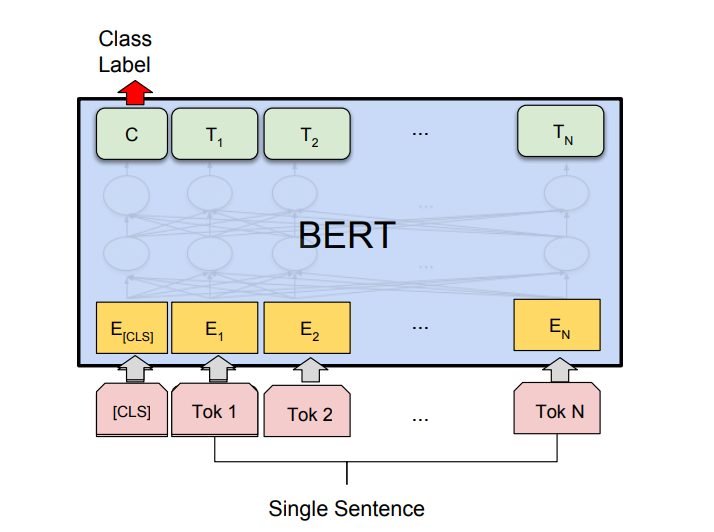

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

bert_name = "distilbert/distilbert-base-uncased"
bert_tok = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_name,
    num_labels=NUM_CLASSES,
)

# Print the number of parameters in the BERT model
num_params = sum(p.numel() for p in bert_model.parameters())
print(f"BERT model parameters: {num_params:,}")

In [ ]:
def tokenize_batch(examples):
    return bert_tok(
        examples["text"],
        truncation=True,
        max_length=256,
    )

bert_ds_train = train_rows.map(tokenize_batch, batched=True)
bert_ds_test = test_rows.map(tokenize_batch, batched=True)
bert_cols = ["input_ids", "attention_mask", "label"]
bert_ds_train.set_format(type="torch", columns=bert_cols)
bert_ds_test.set_format(type="torch", columns=bert_cols)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_ids = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, pred_ids),
        "macro_f1": f1_score(labels, pred_ids, average="macro"),
    }

args = TrainingArguments(
    output_dir="./bert_sentiment_imdb",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    logging_steps=100,
    seed=SEED,
    lr_scheduler_type="linear", # Transformers are trained with linear learning rate scheduler
    warmup_ratio=0.1, # 10% of training steps for warmup
)

trainer = Trainer(
    model=bert_model,
    args=args,
    train_dataset=bert_ds_train,
    eval_dataset=bert_ds_test,
    processing_class=bert_tok,
    compute_metrics=compute_metrics,  
)

print("Training BERT...")
trainer.train()
print("Done.")


from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)
print("Evaluating:", trainer.evaluate())

In [ ]:
# Inference of the BERT model

bert_model.eval()
bert_model.to(device)

examples = [
    "This movie was absolutely wonderful!",
    "I hated this film. It was terrible.",
    "A truly average experience, nothing special.",
    "Brilliant acting and great story.",
    "Worst movie ever.",
]

inputs = bert_tok(
    examples,
    truncation=True,
    max_length=256,
    padding=True,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    preds = bert_model(**inputs).logits.argmax(dim=-1).cpu().numpy()

bert_label_map = {0: "Negative", 1: "Positive"}
for text, pred in zip(examples, preds):
    print(f"Text: {text}\nPredicted label: {bert_label_map.get(pred, pred)}\n")

# 4. Fasttext: efficient classification on CPU

Supervised FastText: linear classifier over word / character *n*-grams. With `pretrainedVectors`, word vectors are **initialized from FastText’s English Wikipedia `.vec` (300-d)** 
and then updated during training on your labels.

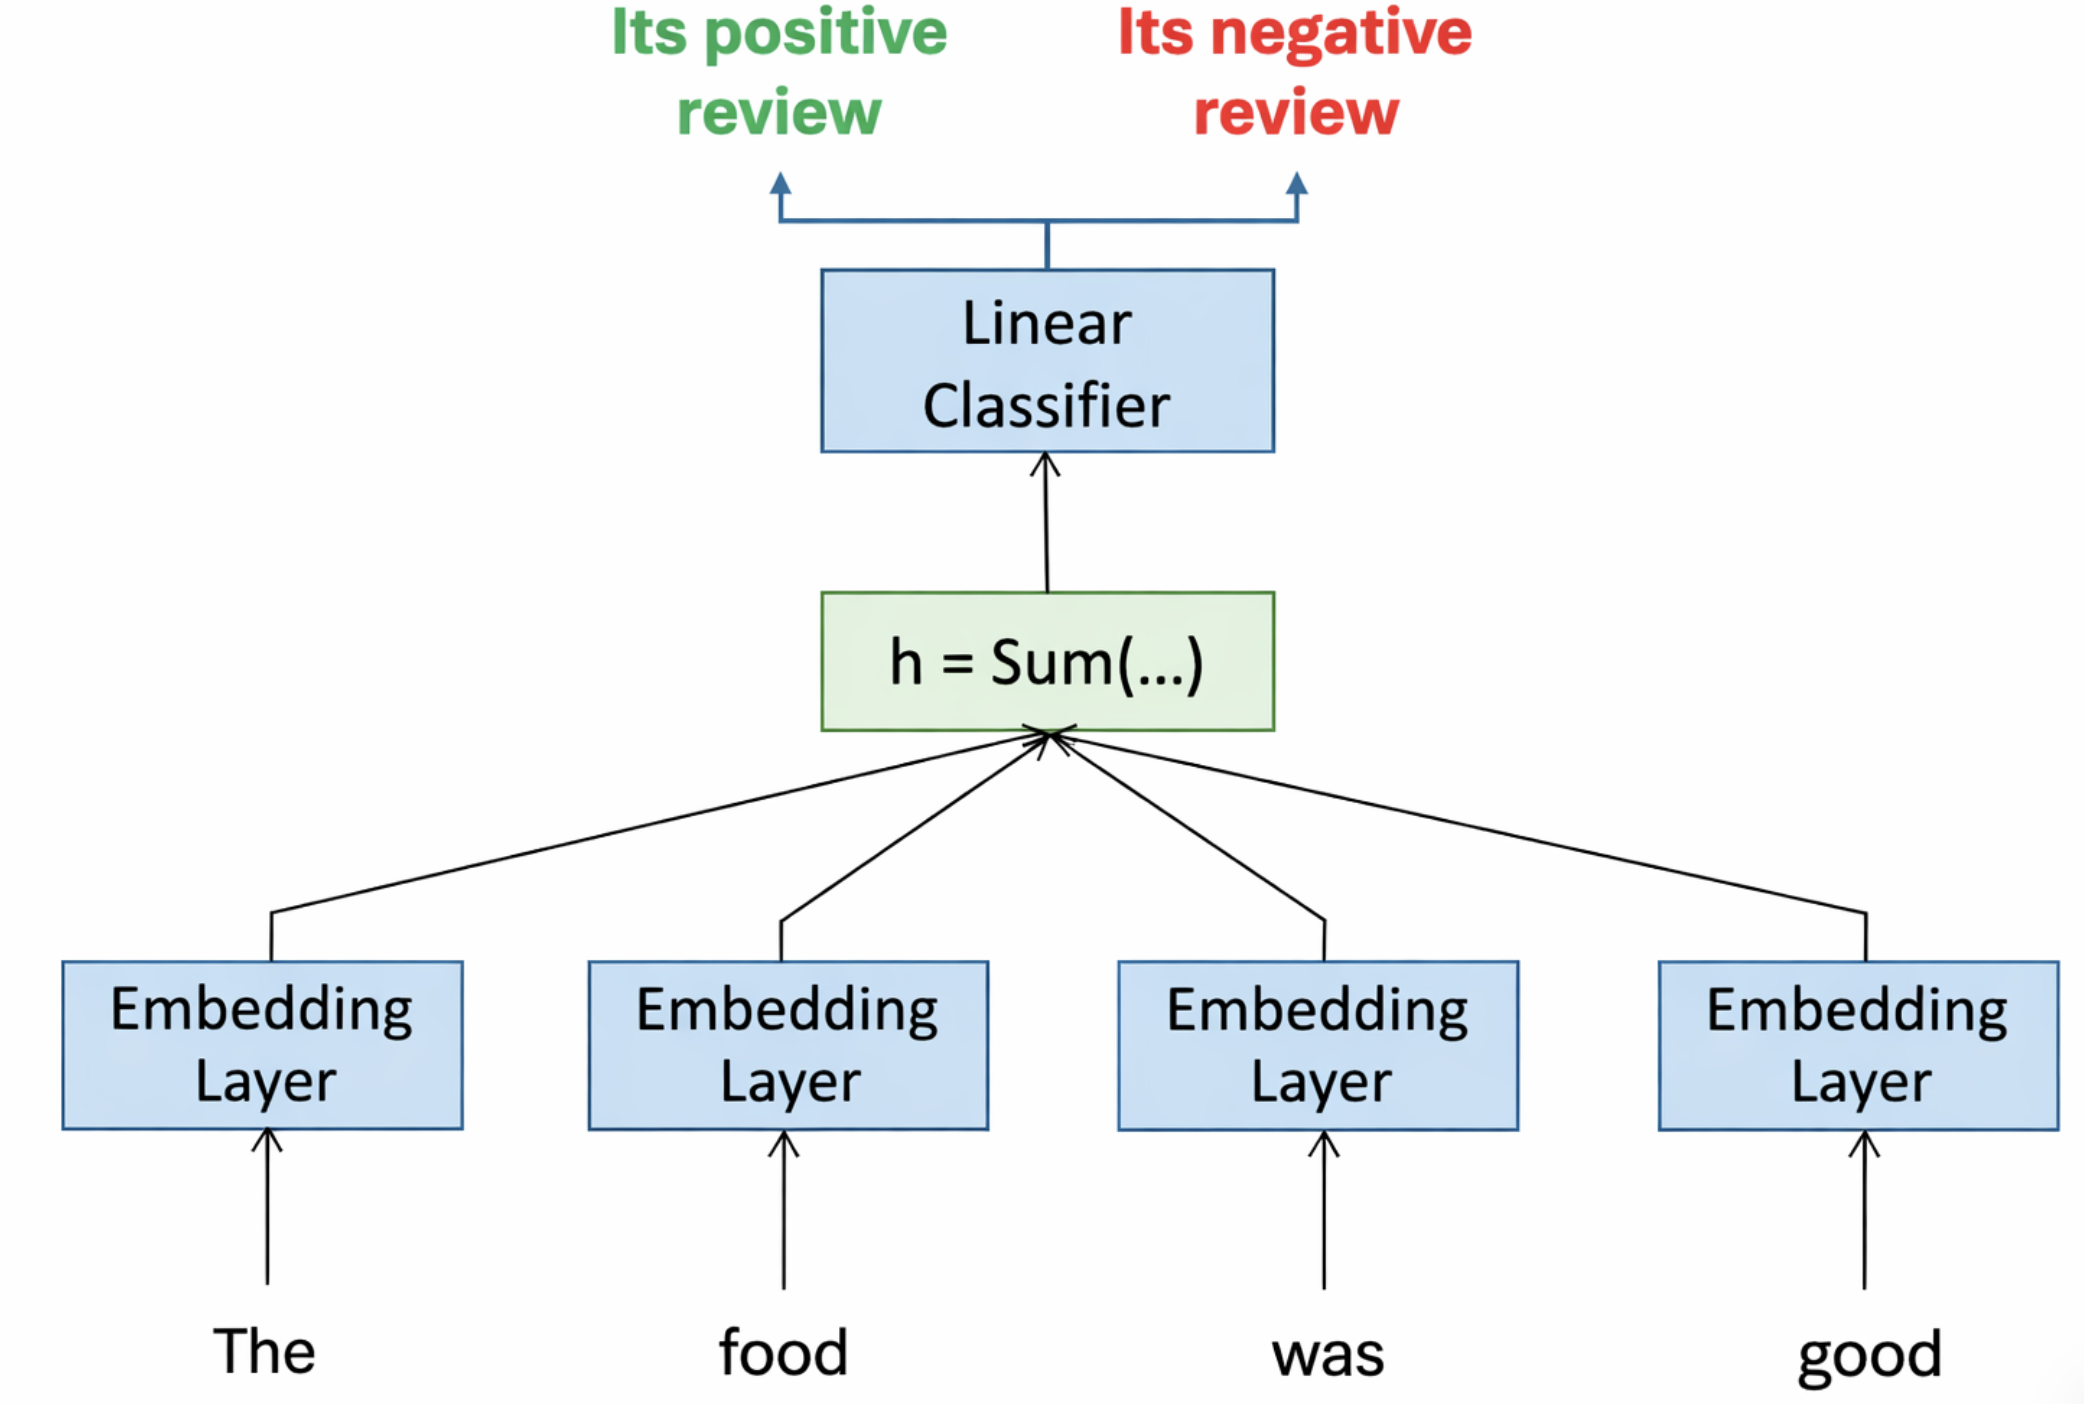

In [ ]:
import urllib.request
import zipfile
from pathlib import Path


# FastText expects one line per example: "__label__<name> <text>"
FT_LABELS = {0: "__label__neg", 1: "__label__pos"}

# English Wikipedia word vectors (300-d .vec). First run downloads ~1.2 GB zip, then caches on disk.
WIKI_EN_VEC_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.en.zip"
PRETRAINED_DIM = 300


def ensure_fasttext_pretrained_vec(cache_dir: Path) -> Path:
    """Return path to wiki.en.vec; download official zip once if missing."""

    cache_dir.mkdir(parents=True, exist_ok=True)
    vec_path = cache_dir / "wiki.en.vec"
    if vec_path.is_file():
        return vec_path

    zip_path = cache_dir / "wiki.en.zip"
    if not zip_path.is_file():
        print(
            "Downloading FastText wiki.en.zip (~1.2 GB, one-time). "
            f"Cache: {cache_dir}\n"
            "To use your own .vec file instead, set FASTTEXT_PRETRAINED_VEC=/path/to/file.vec"
        )
        urllib.request.urlretrieve(WIKI_EN_VEC_URL, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zf:
        members = [n for n in zf.namelist() if n.rstrip("/").endswith(".vec")]
        if not members:
            raise RuntimeError("wiki.en.zip contains no .vec file")
            
        zf.extract(members[0], cache_dir)
        extracted = cache_dir / members[0]
    
    if not extracted.is_file():
        raise FileNotFoundError(f"Expected {extracted} after extract")

    if extracted.resolve() != vec_path.resolve():
        extracted.replace(vec_path)

    zip_path.unlink(missing_ok=True)

    return vec_path


print("Loading FastText pretrained vectors...")
CACHE_DIR = "fasttext_cache"
pretrained_vec = ensure_fasttext_pretrained_vec(Path(CACHE_DIR))
print("Done.")

In [ ]:
from pathlib import Path
import tempfile
import fasttext
from sklearn.metrics import accuracy_score, f1_score


def texts_to_fasttext_path(texts, labels, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        for text, label in zip(texts, labels):
            text = text.replace("\n", " ").replace("\r", " ").strip()
            if text:
                f.write(f"{FT_LABELS[int(label)]} {text}\n")


print("Training FastText...")
with tempfile.TemporaryDirectory() as tmp:
    train_ft = Path(tmp) / "imdb_train.ft"
    texts_to_fasttext_path(train_texts, train_labels, train_ft)

    ft_model = fasttext.train_supervised(
        input=str(train_ft),
        epoch=10,
        lr=0.5,
        wordNgrams=2,
        minCount=1,
        loss="softmax",
        dim=PRETRAINED_DIM,
        pretrainedVectors=str(pretrained_vec),
    )
print("Done.")


def fasttext_predict_labels(texts, model):
    def preprocess_for_fasttext(text: str) -> str:
        return text.replace("\n", " ").replace("\r", " ").strip() or " "

    lines = [preprocess_for_fasttext(t) for t in texts]
    labels, _ = model.predict(lines)
    preds = [1 if lab[0] == "__label__pos" else 0 for lab in labels]

    return preds


print("Evaluatign FastText...")
ft_preds = fasttext_predict_labels(test_texts, ft_model)

print(
    "FastText (supervised + pretrained wiki.en.vec) test accuracy:",
    round(accuracy_score(test_labels, ft_preds), 4),
)
print(
    "FastText (supervised + pretrained wiki.en.vec) test macro-F1:",
    round(f1_score(test_labels, ft_preds, average="macro"), 4),
)

In [ ]:
# Example of using FastText classifier

examples = [
    "This movie was absolutely wonderful!",
    "I hated this film. It was terrible.",
    "A truly average experience, nothing special.",
    "Brilliant acting and great story.",
    "Worst movie ever.",
]

ft_preds = fasttext_predict_labels(examples, ft_model)
label_map = {0: "Negative", 1: "Positive"}
for text, pred in zip(examples, preds):
    print(f"Text: {text}\nPredicted label: {label_map.get(pred, pred)}\n")

# Task

1. Explore other datasets: "cornell-movie-review-data/rotten_tomatoes", "dair-ai/emotion", "fancyzhx/ag_news". What performance do you achieve on these datasets, which model was the best? What is the most challenging dataset?
2. On the most challenging dataset try different embeddings. Did you achieve any improvement?
3. On the most challenging dataset try different pre-trained MLM models: RoBERTa, DeBERTa, ELECTRA. What MLM was the best and what was the performance?
4. Generate a short 0.5-1 page report with charts or tables about your findings.